# Data Loading and Preprocessing

Import Libraries

In [30]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np

Load Dataset

In [31]:
# Load Iris dataset
iris = load_iris(as_frame=True)
df = iris.frame

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


Select Features

In [32]:
features = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)']
label = 'target'

X = df[features]
y = df[label]

Split Data

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

Save as csv

In [34]:
train_data = pd.concat([X_train, y_train], axis=1)
val_data = pd.concat([X_val, y_val], axis=1)

train_data.to_csv("iris_train.csv", index=False)
val_data.to_csv("iris_val.csv", index=False)

Convert csv files to numpy arrays

In [35]:
train_df = pd.read_csv("iris_train.csv")
val_df = pd.read_csv("iris_val.csv")

Xtrain = train_df[features].to_numpy()
ytrain = train_df[label].to_numpy()

Xval = val_df[features].to_numpy()
yval = val_df[label].to_numpy()

Feature Scaling

In [36]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

Xtrain = scaler.fit_transform(Xtrain)
Xval = scaler.transform(Xval)

In [37]:
print("Xtrain (5 rows):")
print(Xtrain[:5])

print("\nytrain (5 values):")
print(ytrain[:5])

print("\nXval (5 rows):")
print(Xval[:5])

print("\nyval (5 values):")
print(yval[:5])

Xtrain (5 rows):
[[0.08823529 0.66666667 0.        ]
 [0.41176471 1.         0.0877193 ]
 [0.70588235 0.45833333 0.59649123]
 [0.14705882 0.58333333 0.10526316]
 [0.02941176 0.5        0.05263158]]

ytrain (5 values):
[0 0 1 0 0]

Xval (5 rows):
[[0.52941176 0.33333333 0.64912281]
 [0.41176471 0.75       0.12280702]
 [1.         0.25       1.03508772]
 [0.5        0.375      0.61403509]
 [0.73529412 0.33333333 0.66666667]]

yval (5 values):
[1 0 2 1 1]


# Cost Function without and with Regularization

Add bias

In [38]:
def add_bias(X):
    m = X.shape[0]
    bias = np.ones((m, 1))
    return np.hstack((bias, X))

Define cost function

In [39]:
def cost_function_no_reg(X, y, w):
    """
    X     : Feature matrix (with bias term)
    y     : Labels
    w     : Weight vector
    """
    m = X.shape[0]
    h = X @ w
    error = h - y
    cost = (1 / (2 * m)) * np.sum(error ** 2)
    return cost

In [40]:
def cost_function_reg(X, y, w, lambd):
    """
    X     : Feature matrix (with bias term)
    y     : Labels
    w     : Weight vector
    lambd : Regularization parameter
    """
    m = X.shape[0]

    # Hypothesis
    h = X @ w

    # Squared error loss
    error = h - y
    cost = (1 / (2 * m)) * np.sum(error ** 2)

    # Regularization (exclude bias term w[0])
    reg = (lambd / (2 * m)) * np.sum(w[1:] ** 2)

    return cost + reg


Prepare data for cost calculation

In [41]:
# Add bias term
Xtrain_b = add_bias(Xtrain)
Xval_b = add_bias(Xval)

# Initialize weights (zeros)
n_features = Xtrain_b.shape[1]
w = np.zeros(n_features)

# Regularization parameter
lambd = 0.1

Compute Cost on Training and Cross Validation sets

In [42]:
# Cost WITHOUT regularization
train_cost_no_reg = cost_function_no_reg(Xtrain_b, ytrain, w)
val_cost_no_reg = cost_function_no_reg(Xval_b, yval, w)

print("WITHOUT Regularization")
print("Training Cost:", train_cost_no_reg)
print("Validation Cost:", val_cost_no_reg)

WITHOUT Regularization
Training Cost: 0.8208333333333333
Validation Cost: 0.8833333333333333


In [43]:
# Cost WITH regularization
train_cost = cost_function_reg(Xtrain_b, ytrain, w, lambd)
val_cost = cost_function_reg(Xval_b, yval, w, lambd)

print("WITH Regularization")
print("Training Cost:", train_cost)
print("Cross-Validation Cost:", val_cost)

WITH Regularization
Training Cost: 0.8208333333333333
Cross-Validation Cost: 0.8833333333333333


After adding non-zero penalty

In [27]:
w = np.random.randn(n_features)

train_cost_no_reg = cost_function_no_reg(Xtrain_b, ytrain, w)
train_cost_reg = cost_function_reg(Xtrain_b, ytrain, w, lambd)

print("No Reg Cost:", train_cost_no_reg)
print("With Reg Cost:", train_cost_reg)
print("Regularization Penalty:", train_cost_reg - train_cost_no_reg)

No Reg Cost: 0.5014766988524219
With Reg Cost: 0.5098255459003413
Regularization Penalty: 0.008348847047919494


# Cost function without and with Gradient Descent

Gradient Descent

In [44]:
def gradient_descent_one_step(X, y, w, alpha, lambd):
    m = X.shape[0]

    h = X @ w
    error = h - y

    grad = (1 / m) * (X.T @ error)
    grad[1:] += (lambd / m) * w[1:]

    return w - alpha * grad

Initialize Parameters

In [46]:
alpha = 0.1
lambd = 0.1

# Initialize weights (including bias)
w = np.zeros(Xtrain_b.shape[1])

Cost Before weight update

In [48]:
train_cost_before = cost_function_reg(Xtrain_b, ytrain, w, lambd)
val_cost_before = cost_function_reg(Xval_b, yval, w, lambd)

print("Before Gradient Descent:")
print("Weights:", w)
print("Training Cost:", train_cost_before)
print("Validation Cost:", val_cost_before)

Before Gradient Descent:
Weights: [0. 0. 0. 0.]
Training Cost: 0.8208333333333333
Validation Cost: 0.8833333333333333


Run Gradient Descent (for one step)

In [49]:
w_updated = gradient_descent_one_step(Xtrain_b, ytrain, w, alpha, lambd)

Cost AFTER weight update

In [50]:
train_cost_after = cost_function_reg(Xtrain_b, ytrain, w_updated, lambd)
val_cost_after = cost_function_reg(Xval_b, yval, w_updated, lambd)

print("\nAfter One Gradient Descent Step:")
print("Updated Weights:", w_updated)
print("Training Cost:", train_cost_after)
print("Validation Cost:", val_cost_after)


After One Gradient Descent Step:
Updated Weights: [0.09916667 0.05897059 0.03715278 0.07097953]
Training Cost: 0.6395306642326152
Validation Cost: 0.6872712393493101


Run Gradient descent for a number of iterations

In [51]:
def gradient_descent(X, y, w, alpha, lambd, num_iters=1000):
    m = X.shape[0]

    for _ in range(num_iters):
        h = X @ w
        error = h - y

        grad = (1 / m) * (X.T @ error)
        grad[1:] += (lambd / m) * w[1:]

        w -= alpha * grad

    return w

In [52]:
w_updated = gradient_descent(Xtrain_b, ytrain, w, alpha, lambd)

Cost Update AFTER 1000 iterations

In [53]:
train_cost_after = cost_function_reg(Xtrain_b, ytrain, w_updated, lambd)
val_cost_after = cost_function_reg(Xval_b, yval, w_updated, lambd)

print("\nAfter One Gradient Descent Step:")
print("Updated Weights:", w_updated)
print("Training Cost:", train_cost_after)
print("Validation Cost:", val_cost_after)


After One Gradient Descent Step:
Updated Weights: [ 0.03839895  0.24284105 -0.42823491  2.16509464]
Training Cost: 0.03783022090000907
Validation Cost: 0.044948521538020585


# Final Training

Main code

Epoch 1/50 | Train Cost: 0.8208 | Val Cost: 0.6873
Epoch 2/50 | Train Cost: 0.6395 | Val Cost: 0.5487
Epoch 3/50 | Train Cost: 0.5121 | Val Cost: 0.4503
Epoch 4/50 | Train Cost: 0.4221 | Val Cost: 0.3801
Epoch 5/50 | Train Cost: 0.3583 | Val Cost: 0.3296
Epoch 6/50 | Train Cost: 0.3127 | Val Cost: 0.2929
Epoch 7/50 | Train Cost: 0.2797 | Val Cost: 0.2660
Epoch 8/50 | Train Cost: 0.2557 | Val Cost: 0.2459
Epoch 9/50 | Train Cost: 0.2379 | Val Cost: 0.2306
Epoch 10/50 | Train Cost: 0.2244 | Val Cost: 0.2188
Epoch 11/50 | Train Cost: 0.2139 | Val Cost: 0.2094
Epoch 12/50 | Train Cost: 0.2056 | Val Cost: 0.2017
Epoch 13/50 | Train Cost: 0.1988 | Val Cost: 0.1953
Epoch 14/50 | Train Cost: 0.1931 | Val Cost: 0.1899
Epoch 15/50 | Train Cost: 0.1882 | Val Cost: 0.1851
Epoch 16/50 | Train Cost: 0.1838 | Val Cost: 0.1807
Epoch 17/50 | Train Cost: 0.1798 | Val Cost: 0.1768
Epoch 18/50 | Train Cost: 0.1762 | Val Cost: 0.1732
Epoch 19/50 | Train Cost: 0.1728 | Val Cost: 0.1698
Epoch 20/50 | Train C

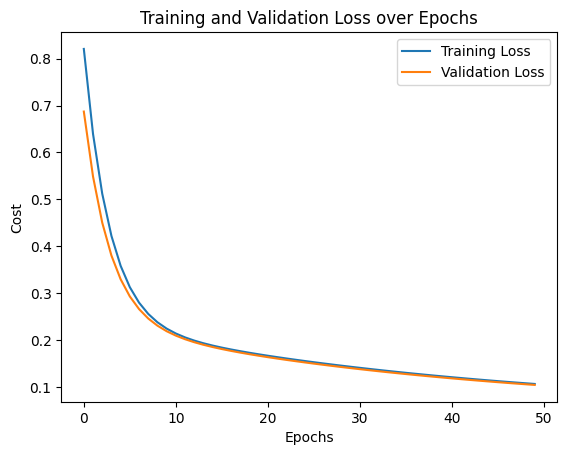

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Hyperparameters
# -----------------------------
alpha = 0.1        # learning rate
lambd = 0.1        # regularization parameter
epochs = 50        # number of epochs

# -----------------------------
# Initialization
# -----------------------------
n_features = Xtrain_b.shape[1]
w = np.zeros(n_features)

train_losses = []
val_losses = []

# -----------------------------
# Training & Validation Loop
# -----------------------------
for epoch in range(epochs):

    # ---- Training cost (before update) ----
    train_cost = cost_function_reg(Xtrain_b, ytrain, w, lambd)

    # ---- Update weights using training data ----
    w = gradient_descent(Xtrain_b, ytrain, w, alpha, lambd, num_iters=1)

    # ---- Validation cost (after update) ----
    val_cost = cost_function_reg(Xval_b, yval, w, lambd)

    # ---- Store losses ----
    train_losses.append(train_cost)
    val_losses.append(val_cost)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Cost: {train_cost:.4f} | "
          f"Val Cost: {val_cost:.4f}")

# -----------------------------
# Final Trained Parameters
# -----------------------------
print("\nFinal Trained Weights:")
print("Bias (w0):", w[0])
print("Feature Weights:", w[1:])

# -----------------------------
# Plot Training vs Validation Loss
# -----------------------------
plt.figure()
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.title("Training and Validation Loss over Epochs")
plt.legend()
plt.show()